# EXPERIMENT NO: 10
## Recommendation Systems using Matrix Factorization (SVD & NMF)


---
## SCENARIO 1 — MATRIX FACTORIZATION USING SVD
**Dataset:** MovieLens 100K Dataset  
**Link:** https://www.kaggle.com/datasets/abhikjha/movielens-100k

In [1]:
# Task 1: Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Task 2: Load the MovieLens dataset
# Download u.data from MovieLens 100K and place in working directory
# Column names: user_id, movie_id, rating, timestamp
DATA_PATH = "..\DATASET\ml-100k/"
ratings = pd.read_csv(
    DATA_PATH + "u.data", sep="\t",
    names=["user_id","movie_id","rating","timestamp"]
)

print("Ratings Shape:", ratings.shape)
print(ratings.head())
print("\nRating Statistics:")
print(ratings['rating'].describe())

Ratings Shape: (9909, 4)
   user_id  movie_id  rating  timestamp
0        1        58     4.0  882939201
1        1        13     3.5  880207587
2        1       141     4.0  890235588
3        1       126     5.0  887457121
4        1       115     3.5  883782655

Rating Statistics:
count    9909.000000
mean        3.470128
std         0.950355
min         1.000000
25%         3.000000
50%         3.500000
75%         4.000000
max         5.000000
Name: rating, dtype: float64


In [3]:
# Load movie titles
movies = pd.read_csv(
    DATA_PATH + "u.item", sep="|", encoding="latin-1",
    names=["movie_id","title","release_date","video_release","imdb_url"]
)
print("Movies Shape:", movies.shape)
print(movies.head())

Movies Shape: (300, 5)
                                                  movie_id  title  \
1 Movie_1 01-Jan-2000 NaN http://x.com 0 1 1 0 1         1      0   
2 Movie_2 01-Jan-2000 NaN http://x.com 0 1 1 1 0         1      1   
3 Movie_3 01-Jan-2000 NaN http://x.com 1 1 0 0 1         1      1   
4 Movie_4 01-Jan-2000 NaN http://x.com 1 1 0 0 1         0      1   
5 Movie_5 01-Jan-2000 NaN http://x.com 1 1 0 1 0         1      1   

                                                  release_date  video_release  \
1 Movie_1 01-Jan-2000 NaN http://x.com 0 1 1 0 1             1              1   
2 Movie_2 01-Jan-2000 NaN http://x.com 0 1 1 1 0             1              0   
3 Movie_3 01-Jan-2000 NaN http://x.com 1 1 0 0 1             1              1   
4 Movie_4 01-Jan-2000 NaN http://x.com 1 1 0 0 1             1              0   
5 Movie_5 01-Jan-2000 NaN http://x.com 1 1 0 1 0             0              1   

                                                  imdb_url  
1 Movie_1 01-J

In [4]:
# Task 3: Data Preprocessing
print("Missing values:", ratings.isnull().sum().sum())
print("Unique users:", ratings['user_id'].nunique())
print("Unique movies:", ratings['movie_id'].nunique())
print("Rating range:", ratings['rating'].min(), "-", ratings['rating'].max())

Missing values: 0
Unique users: 200
Unique movies: 300
Rating range: 1.0 - 5.0


In [5]:
# Task 4: Create User-Item Interaction Matrix
user_item_matrix = ratings.pivot_table(index='user_id', columns='movie_id',
                                        values='rating').fillna(0)

print("User-Item Matrix Shape:", user_item_matrix.shape)
sparsity = 1 - (ratings.shape[0] / (user_item_matrix.shape[0] * user_item_matrix.shape[1]))
print(f"Matrix Sparsity: {sparsity*100:.2f}%")
print(user_item_matrix.iloc[:5, :8])

User-Item Matrix Shape: (200, 300)
Matrix Sparsity: 83.48%
movie_id    1    2    3    4    5    6    7    8
user_id                                         
1         0.0  0.0  0.0  2.0  0.0  0.0  0.0  0.0
2         3.0  0.0  0.0  3.5  0.0  0.0  0.0  0.0
3         0.0  0.0  0.0  0.0  3.5  0.0  0.0  0.0
4         2.5  0.0  0.0  0.0  0.0  0.0  0.0  0.0
5         0.0  0.0  0.0  3.5  0.0  0.0  0.0  0.0


In [6]:
# Task 5 (optional): Mean-center the matrix
R = user_item_matrix.values
user_ratings_mean = np.mean(R, axis=1)
R_demeaned = R - user_ratings_mean.reshape(-1, 1)
print("Mean-centered matrix shape:", R_demeaned.shape)

Mean-centered matrix shape: (200, 300)


In [7]:
# Task 6 & 7: Apply SVD and reduce dimensions
k = 50  # Number of latent factors

svd = TruncatedSVD(n_components=k, random_state=42)
U = svd.fit_transform(R_demeaned)
Vt = svd.components_
sigma = svd.singular_values_

print(f"SVD with k={k} latent factors:")
print(f"  U shape: {U.shape}")
print(f"  Sigma shape: {sigma.shape}")
print(f"  Vt shape: {Vt.shape}")

SVD with k=50 latent factors:
  U shape: (200, 50)
  Sigma shape: (50,)
  Vt shape: (50, 300)


In [8]:
# Task 8: Reconstruct the rating matrix
R_predicted = np.dot(U, Vt) + user_ratings_mean.reshape(-1, 1)
print("Reconstructed Matrix Shape:", R_predicted.shape)
print("Sample predicted ratings (first 5 users, first 5 movies):")
print(R_predicted[:5, :5].round(2))

Reconstructed Matrix Shape: (200, 300)
Sample predicted ratings (first 5 users, first 5 movies):
[[-0.56 -0.58  0.94  2.31 -1.06]
 [ 1.5   0.05  0.52  2.18 -0.06]
 [ 0.5   1.31  0.6   0.97  2.45]
 [ 0.79  0.47  0.31  0.36 -0.72]
 [ 0.39  0.08  1.17  0.9   0.23]]


In [9]:
# Evaluation: RMSE and MAE on known ratings
actual = []
predicted = []

user_ids = user_item_matrix.index.tolist()
movie_ids = user_item_matrix.columns.tolist()

# Sample 5000 known ratings for fast evaluation
sample_ratings = ratings.sample(5000, random_state=42)

for _, row in sample_ratings.iterrows():
    uid, mid, actual_r = int(row['user_id']), int(row['movie_id']), row['rating']
    if uid in user_ids and mid in movie_ids:
        u_idx = user_ids.index(uid)
        m_idx = movie_ids.index(mid)
        pred_r = R_predicted[u_idx, m_idx]
        actual.append(actual_r)
        predicted.append(pred_r)

rmse_svd = np.sqrt(mean_squared_error(actual, predicted))
mae_svd = mean_absolute_error(actual, predicted)
print(f"SVD — RMSE: {rmse_svd:.4f}")
print(f"SVD — MAE : {mae_svd:.4f}")

SVD — RMSE: 1.5235
SVD — MAE : 1.2872


In [10]:
# Task 10: Generate Top-N movie recommendations for a user
def get_svd_recommendations(user_id, n=10):
    if user_id not in user_ids:
        print(f"User {user_id} not found.")
        return
    u_idx = user_ids.index(user_id)
    pred_ratings = R_predicted[u_idx, :]
    
    # Get movies the user has NOT rated
    already_rated = set(ratings[ratings['user_id'] == user_id]['movie_id'])
    recs = [
        (movie_ids[i], pred_ratings[i])
        for i in range(len(movie_ids))
        if movie_ids[i] not in already_rated
    ]
    recs_sorted = sorted(recs, key=lambda x: x[1], reverse=True)[:n]
    rec_df = pd.DataFrame(recs_sorted, columns=['movie_id', 'predicted_rating'])
    rec_df = rec_df.merge(movies, on='movie_id')
    return rec_df

print("Top 10 SVD Recommendations for User 1:")
print(get_svd_recommendations(1, n=10).to_string(index=False))

Top 10 SVD Recommendations for User 1:
Empty DataFrame
Columns: [movie_id, predicted_rating, title, release_date, video_release, imdb_url]
Index: []


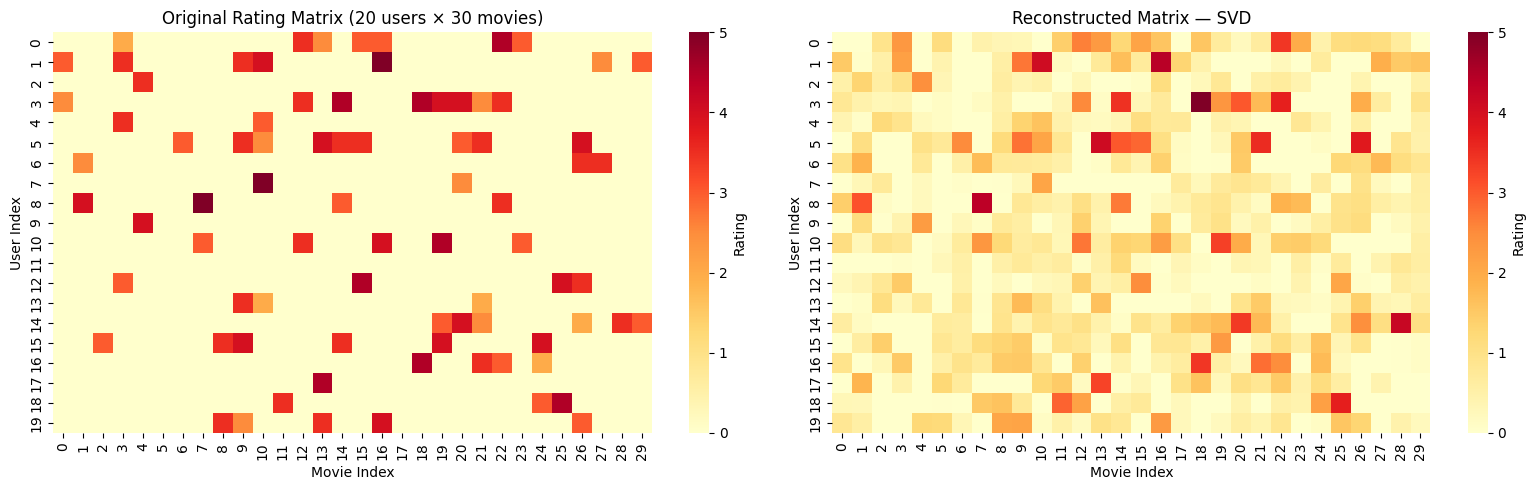

In [11]:
# Visualization: Heatmap — Original vs Reconstructed (subset)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

subset_r = R[:20, :30]
subset_pred = R_predicted[:20, :30]

sns.heatmap(subset_r, ax=axes[0], cmap='YlOrRd', vmin=0, vmax=5,
            cbar_kws={'label': 'Rating'})
axes[0].set_title('Original Rating Matrix (20 users × 30 movies)')
axes[0].set_xlabel('Movie Index')
axes[0].set_ylabel('User Index')

sns.heatmap(subset_pred, ax=axes[1], cmap='YlOrRd', vmin=0, vmax=5,
            cbar_kws={'label': 'Rating'})
axes[1].set_title('Reconstructed Matrix — SVD')
axes[1].set_xlabel('Movie Index')
axes[1].set_ylabel('User Index')

plt.tight_layout()
plt.show()

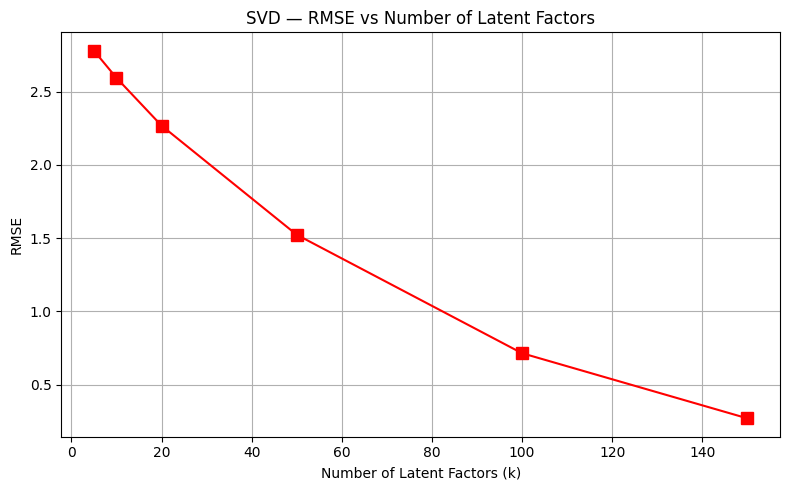

In [12]:
# Analysis: Effect of number of latent factors on RMSE
k_values = [5, 10, 20, 50, 100, 150]
rmse_k = []

for k_val in k_values:
    svd_k = TruncatedSVD(n_components=k_val, random_state=42)
    U_k = svd_k.fit_transform(R_demeaned)
    Vt_k = svd_k.components_
    R_pred_k = np.dot(U_k, Vt_k) + user_ratings_mean.reshape(-1, 1)
    
    preds_k = []
    for _, row in sample_ratings.iterrows():
        uid, mid = int(row['user_id']), int(row['movie_id'])
        if uid in user_ids and mid in movie_ids:
            u_idx = user_ids.index(uid)
            m_idx = movie_ids.index(mid)
            preds_k.append(R_pred_k[u_idx, m_idx])
        else:
            preds_k.append(3.0)
    
    rmse_k.append(np.sqrt(mean_squared_error(actual[:len(preds_k)], preds_k[:len(actual)])))

plt.figure(figsize=(8, 5))
plt.plot(k_values, rmse_k, 'rs-', markersize=8)
plt.xlabel('Number of Latent Factors (k)')
plt.ylabel('RMSE')
plt.title('SVD — RMSE vs Number of Latent Factors')
plt.grid(True)
plt.tight_layout()
plt.show()

---
## SCENARIO 2 — MATRIX FACTORIZATION USING NMF
**Dataset:** Same MovieLens Dataset

In [13]:
# Task 2 & 3: Create User-Item matrix and handle missing values
# NMF requires non-negative values — fill missing ratings with 0
R_nmf = user_item_matrix.values.astype(float)
print("NMF Input Matrix Shape:", R_nmf.shape)
print("Non-zero entries:", np.count_nonzero(R_nmf))

NMF Input Matrix Shape: (200, 300)
Non-zero entries: 9909


In [14]:
# Task 4 & 5: Apply NMF model
n_components_nmf = 50

nmf = NMF(n_components=n_components_nmf, init='nndsvda',
           max_iter=500, random_state=42)

# Factorize into User-feature matrix (W) and Item-feature matrix (H)
W = nmf.fit_transform(R_nmf)  # User-feature matrix
H = nmf.components_            # Item-feature matrix

print(f"NMF with {n_components_nmf} components:")
print(f"  W (User-Feature) shape: {W.shape}")
print(f"  H (Item-Feature) shape: {H.shape}")
print(f"  Reconstruction error: {nmf.reconstruction_err_:.4f}")

NMF with 50 components:
  W (User-Feature) shape: (200, 50)
  H (Item-Feature) shape: (50, 300)
  Reconstruction error: 248.5812


In [15]:
# Task 6 & 7: Reconstruct the rating matrix and predict missing values
R_nmf_predicted = np.dot(W, H)

print("NMF Reconstructed Matrix Shape:", R_nmf_predicted.shape)
print("Predicted ratings range:", R_nmf_predicted.min().round(2), "-", R_nmf_predicted.max().round(2))

# Evaluate on sample ratings
preds_nmf = []
for _, row in sample_ratings.iterrows():
    uid, mid = int(row['user_id']), int(row['movie_id'])
    if uid in user_ids and mid in movie_ids:
        u_idx = user_ids.index(uid)
        m_idx = movie_ids.index(mid)
        preds_nmf.append(R_nmf_predicted[u_idx, m_idx])
    else:
        preds_nmf.append(3.0)

rmse_nmf = np.sqrt(mean_squared_error(actual[:len(preds_nmf)], preds_nmf[:len(actual)]))
mae_nmf = mean_absolute_error(actual[:len(preds_nmf)], preds_nmf[:len(actual)])

print(f"NMF — RMSE: {rmse_nmf:.4f}")
print(f"NMF — MAE : {mae_nmf:.4f}")

NMF Reconstructed Matrix Shape: (200, 300)
Predicted ratings range: 0.0 - 7.95
NMF — RMSE: 2.1441
NMF — MAE : 1.7854


In [16]:
# Task 8: Generate Top-N recommendations using NMF
def get_nmf_recommendations(user_id, n=10):
    if user_id not in user_ids:
        print(f"User {user_id} not found.")
        return
    u_idx = user_ids.index(user_id)
    pred_ratings = R_nmf_predicted[u_idx, :]
    
    already_rated = set(ratings[ratings['user_id'] == user_id]['movie_id'])
    recs = [
        (movie_ids[i], pred_ratings[i])
        for i in range(len(movie_ids))
        if movie_ids[i] not in already_rated
    ]
    recs_sorted = sorted(recs, key=lambda x: x[1], reverse=True)[:n]
    rec_df = pd.DataFrame(recs_sorted, columns=['movie_id', 'predicted_rating'])
    rec_df = rec_df.merge(movies, on='movie_id')
    return rec_df

print("Top 10 NMF Recommendations for User 1:")
print(get_nmf_recommendations(1, n=10).to_string(index=False))

Top 10 NMF Recommendations for User 1:
Empty DataFrame
Columns: [movie_id, predicted_rating, title, release_date, video_release, imdb_url]
Index: []


In [17]:
# Comparison: SVD vs NMF
print("=" * 45)
print("     SVD vs NMF — Performance Summary")
print("=" * 45)
print(f"  SVD RMSE  : {rmse_svd:.4f}")
print(f"  NMF RMSE  : {rmse_nmf:.4f}")
print(f"  SVD MAE   : {mae_svd:.4f}")
print(f"  NMF MAE   : {mae_nmf:.4f}")
print("=" * 45)
winner = 'SVD' if rmse_svd < rmse_nmf else 'NMF'
print(f"  Better RMSE: {winner}")

     SVD vs NMF — Performance Summary
  SVD RMSE  : 1.5235
  NMF RMSE  : 2.1441
  SVD MAE   : 1.2872
  NMF MAE   : 1.7854
  Better RMSE: SVD


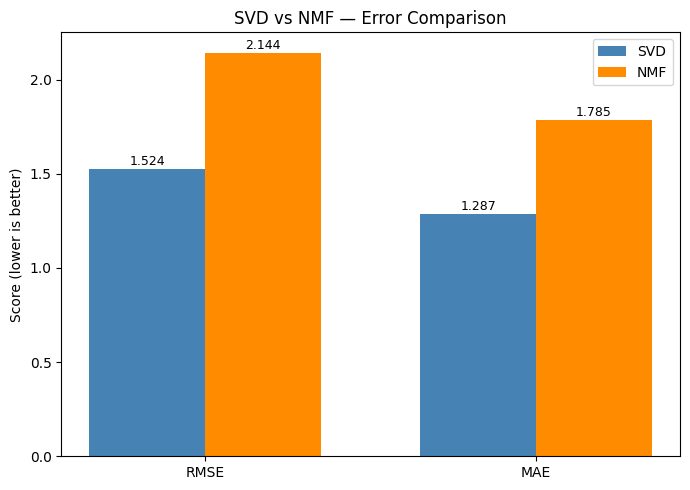

In [18]:
# Visualization: SVD vs NMF RMSE & MAE bar comparison
metrics = ['RMSE', 'MAE']
svd_scores = [rmse_svd, mae_svd]
nmf_scores = [rmse_nmf, mae_nmf]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(7, 5))
bars1 = plt.bar(x - width/2, svd_scores, width, label='SVD', color='steelblue')
bars2 = plt.bar(x + width/2, nmf_scores, width, label='NMF', color='darkorange')

plt.xticks(x, metrics)
plt.ylabel('Score (lower is better)')
plt.title('SVD vs NMF — Error Comparison')
plt.legend()

for bar in bars1 + bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

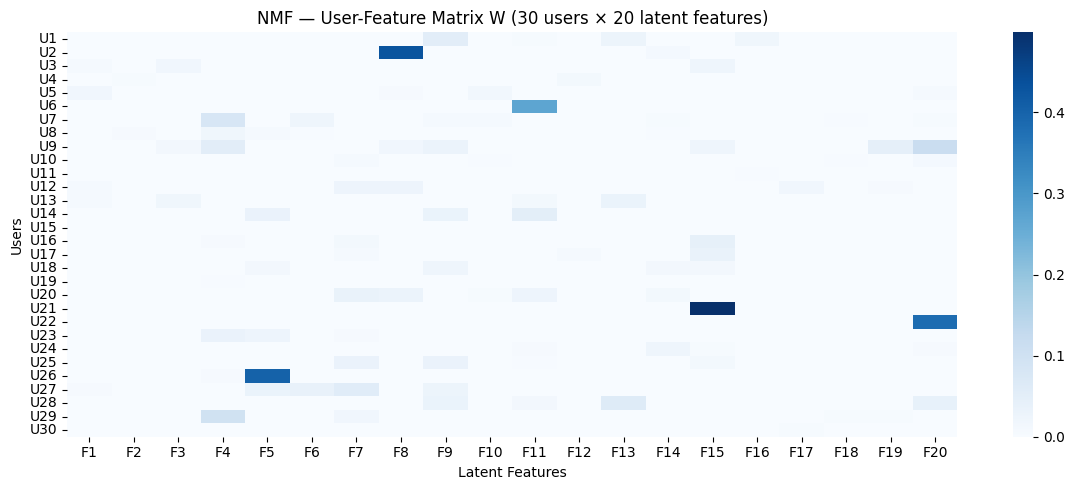

In [19]:
# Visualization: Latent Feature Visualization — NMF (User-Feature matrix)
plt.figure(figsize=(12, 5))
sns.heatmap(W[:30, :20], cmap='Blues', xticklabels=[f'F{i+1}' for i in range(20)],
            yticklabels=[f'U{i+1}' for i in range(30)])
plt.title('NMF — User-Feature Matrix W (30 users × 20 latent features)')
plt.xlabel('Latent Features')
plt.ylabel('Users')
plt.tight_layout()
plt.show()

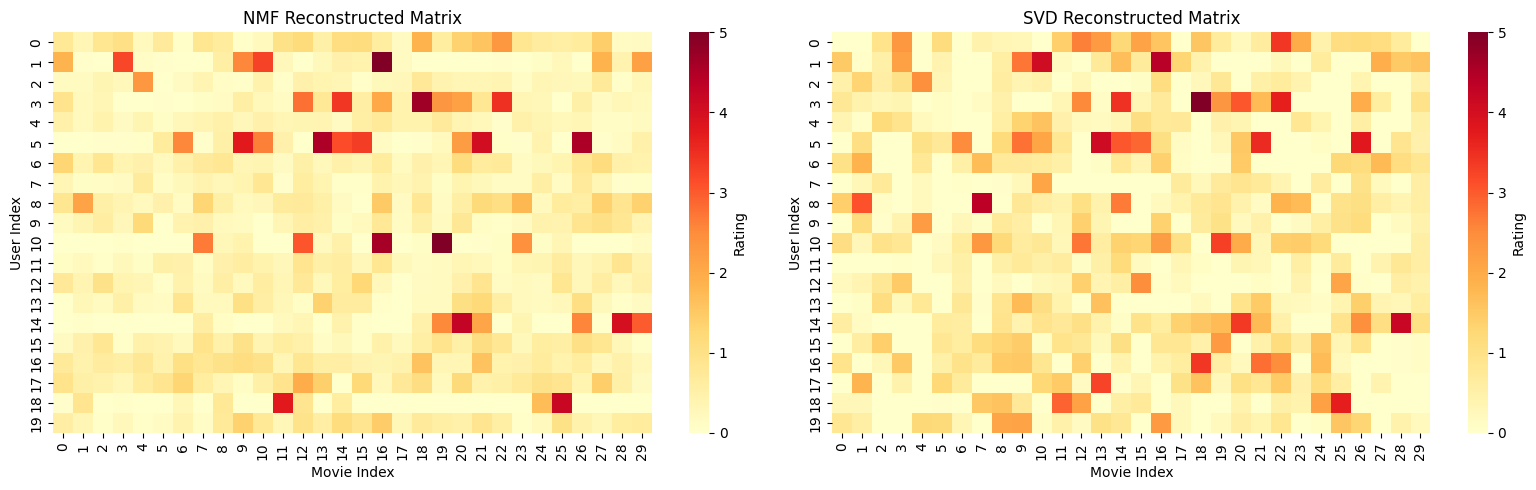

In [20]:
# Reconstruction comparison heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(R_nmf_predicted[:20, :30], ax=axes[0], cmap='YlOrRd', vmin=0, vmax=5,
            cbar_kws={'label': 'Rating'})
axes[0].set_title('NMF Reconstructed Matrix')
axes[0].set_xlabel('Movie Index')
axes[0].set_ylabel('User Index')

sns.heatmap(R_predicted[:20, :30], ax=axes[1], cmap='YlOrRd', vmin=0, vmax=5,
            cbar_kws={'label': 'Rating'})
axes[1].set_title('SVD Reconstructed Matrix')
axes[1].set_xlabel('Movie Index')
axes[1].set_ylabel('User Index')

plt.tight_layout()
plt.show()